<a href="https://colab.research.google.com/github/tiagobventura/ANACOR-Compras/blob/main/An%C3%A1lise_de_Correspond%C3%AAncia_Compras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install prince
!pip install adjustText

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 3.7 MB/s eta 0:00:00


# Importação das bibliotecas

In [2]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Análise de correspondência e estatística chi2
import prince
import scipy.stats as stats

# Visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text # similar ao ggrepel do R

# Tratamentos dos dados(Data Wrangling)

In [21]:
#Adicione na variável o diretório de sua base de dados.
diretorio = '/content/drive/MyDrive/Dataset/datasets/SuperMarket Analysis.csv';

df = pd.read_csv(diretorio)

df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


In [4]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [23]:
#Renomeando as colunas.
df.rename(columns={'Product line': 'product_line'}, inplace=True)
df.rename(columns={'Payment': 'payment'}, inplace=True)
df.rename(columns={'City': 'city'}, inplace=True)
df.rename(columns={'Branch': 'branch'}, inplace=True)
df.rename(columns={'Customer type': 'customer_type'}, inplace=True)

In [6]:
df

,Invoice ID,branch,city,customer_type,Gender,product_line,Unit price,Quantity,Tax 5%,Sales,Date,Time,payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


In [7]:
df.product_line.unique()

array(['Health and beauty', 'Electronic accessories',
       'Home and lifestyle', 'Sports and travel', 'Food and beverages',
       'Fashion accessories'], dtype=object)

In [8]:
df.payment.unique()

array(['Ewallet', 'Cash', 'Credit card'], dtype=object)

In [9]:
df

,Invoice ID,branch,city,customer_type,Gender,product_line,Unit price,Quantity,Tax 5%,Sales,Date,Time,payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


In [10]:
df.product_line.value_counts()

,count
product_line,
Fashion accessories,178
Food and beverages,174
Electronic accessories,170
Sports and travel,166
Home and lifestyle,160
Health and beauty,152


In [11]:
tbl_contigencia_compras = pd.crosstab(df.product_line, df.payment)
display(tbl_contigencia_compras)

payment,Cash,Credit card,Ewallet
product_line,,,
Electronic accessories,71,46,53
Fashion accessories,57,56,65
Food and beverages,57,61,56
Health and beauty,49,50,53
Home and lifestyle,51,45,64
Sports and travel,59,53,54


# Processamento ANACOR

In [12]:
chi2, pvalor, graus_liberdade, valores_esperados = stats.chi2_contingency(tbl_contigencia_compras)
print(f'chi2 = {chi2:.2f} e p-valor = {pvalor}')

chi2 = 8.72 e p-valor = 0.5587284263994264


In [13]:
#Num. de dimensões
ndim = (np.array(tbl_contigencia_compras)-1).min()

#Criando o modelo ANACOR
ca = prince.CA(n_components=ndim)
ca = ca.fit(tbl_contigencia_compras)

In [14]:
chart = ca.plot(tbl_contigencia_compras)
chart.show()

alt.LayerChart(...)

In [15]:
# Definir um layout para os gráficos
sns.set_theme(
    context='talk', style='ticks', palette='husl', font_scale=1.2,
    rc={'font.weight':'regular', 'axes.labelpad':15, 'axes.titlepad':30}
)

# Definir um gráfico customizado
def plot_ca(model, ct, ax, title):
    rc = model.row_coordinates(ct)
    x,y = rc[0],rc[1]

    ax.plot(x, y, 'o', markersize=20, alpha=.9, label=tbl_contigencia_compras.index.name.title())

    texts1 = [ax.text(x[i], y[i], rc.index[i], fontsize='medium') for i in range(len(x))]
    #adjust_text(texts1, arrowprops=dict(arrowstyle='-', color='black'))

    cc = ca.column_coordinates(tbl_contigencia_compras)
    x,y = cc[0],cc[1]

    ax.plot(x, y, '*', markersize=35, label=tbl_contigencia_compras.columns.name.title())
    texts2 = [
        ax.text(x[i], y[i], cc.index[i], fontsize='large', fontweight='bold',
                 #fontsize='medium', #fontfamily='Ubuntu',
                 color='#baa01f', fontstretch=1000)
        for i in range(len(x))
    ]

    adjust_text(texts1+texts2)
    ei = ca.percentage_of_variance_#explained_inertia_

    ax.set_title(title, fontsize=24, fontweight=1000, loc='center')
    ax.set_xlabel('Componente {} ({:.2f}% inércia)'.format(1, 100 * ei[0]), fontsize='small')
    ax.set_ylabel('Componente {} ({:.2f}% inércia)'.format(2, 100 * ei[1]), fontsize='small')
    ax.grid()
    ax.legend()
    return ax

# Resultado

/tmp/ipykernel_3792/1948191571.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts1 = [ax.text(x[i], y[i], rc.index[i], fontsize='medium') for i in range(len(x))]
/tmp/ipykernel_3792/1948191571.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(x[i], y[i], cc.index[i], fontsize='large', fontweight='bold',
/tmp/ipykernel_3792/633709208.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='payment', data=df, palette='viridis', order=sorted(df.payment.

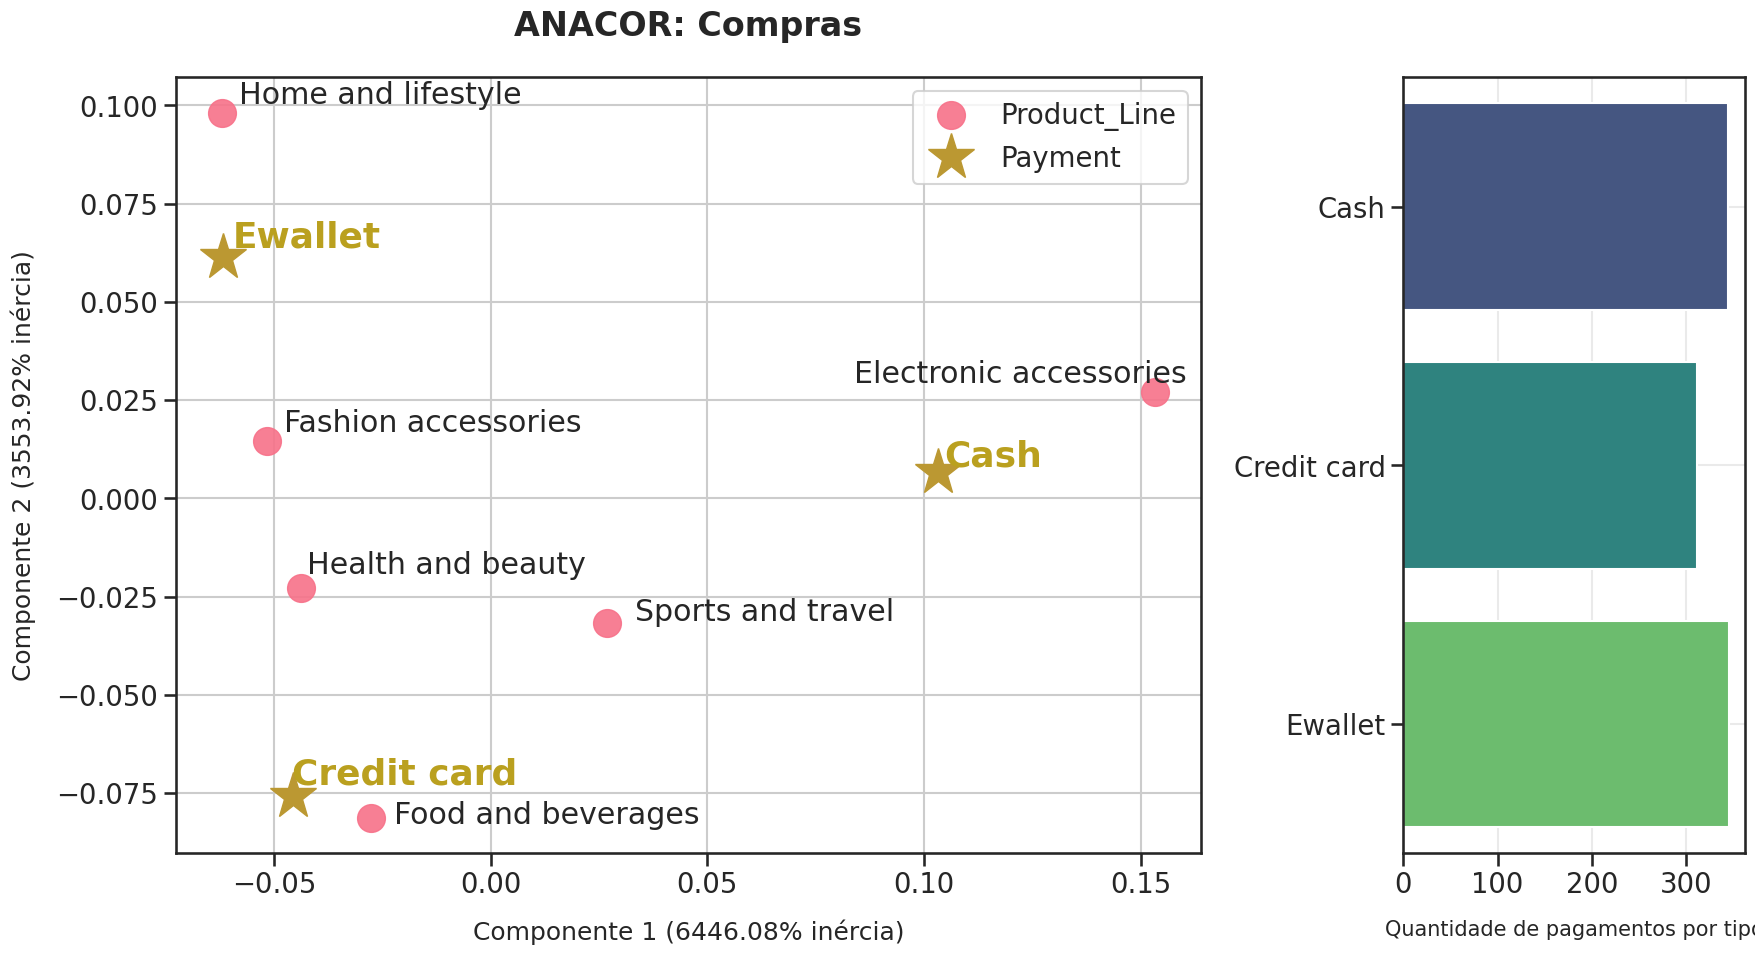

In [20]:
fig, (ax1,ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [3, 1]}, figsize=(18,10))

ax1 = plt.subplot(1,2,1)
plot_ca(ca, tbl_contigencia_compras, ax1, title='ANACOR: Compras')

ax2 = plt.subplot(1,2,2)
#No parâmetro y colocar o nome da coluna.
sns.countplot(y='payment', data=df, palette='viridis', order=sorted(df.payment.unique()), ax=ax2)
ax2.set_ylabel(None)
ax2.set_xlabel('Quantidade de pagamentos por tipo', fontsize='x-small')
ax2.grid(alpha=0.4)

fig.tight_layout()
plt.show()

# Conclusão

Observa-se que a quantidade de dados por tipo de pagamento tem quantidade aproximada entre eles.
O pagamento da maioria das linhas de produtos, de segmentos são concentrados em ewllet(Carteira digital) e cartão crédito, o pagamento em dinheiro tem mais relevância nos acessórios eletrônicos(Electronic accessories).
Nota-se a concentração dos pagamento em cartão de crédito(Credit Card) para alimentação(Food and beverages).
